# **`CAPSTONE PROJECT_LOAN DEFAULT`**





## Context
A major proportion of retail bank profit comes from interests in the form of home loans. These loans are borrowed by regular income/high-earning customers. Banks are most fearful of defaulters, as bad loans (NPA) usually eat up a major chunk of their profits. Therefore, it is important for banks to be judicious while approving loans for their customer base. The approval process for the loans is multifaceted. Through this process, the bank tries to check the creditworthiness of the applicant on the basis of a manual study of various aspects of the application. The entire process is not only eﬀort-intensive but also prone to wrong judgment/approval owing to human error and biases. There have been attempts by many banks to automate this process by using heuristics. But with the advent of data science and machine learning, the focus has shifted to building machines that can learn this approval process and make it free of biases and more eﬃcient. At the same time, one important thing to keep in mind is to make sure that the machine does not learn the biases that previously crept in because of the human approval process.

## Problem Statement
A bank's consumer credit department aims to simplify the decision-making process for home equity lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's guidelines to establish an empirically derived and statistically sound model for credit scoring. The model will be based on the data obtained via the existing loan underwriting process from recent applicants who have been given credit. The model will be built from predictive modeling techniques, but the model created must be interpretable enough to provide a justification for any adverse behavior (rejections).

## Objective
Build a classification model to predict clients who are likely to default on their loan and give recommendations to the bank on the important features to consider while approving a loan.

# Installing and Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

import statsmodels.api as sm

# Import necessary components for pipelines
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Scikit-learn for machine learning models and utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# Imblearn for handling imbalanced datasets
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost for gradient boosting
import xgboost as xgb

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Data Overview

## Loading the Data

In [2]:
# this code gives colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# this code reads the csv file referenced in the parenthesis.
path_csv = '/content/drive/MyDrive/MS Data Science & Business Analytics/Bridge course/Capstone/Loan Default.csv'
df_loan = pd.read_csv(path_csv)

In [4]:
# this code creates a copy of the dataset
df = df_loan.copy()

## Examining the Data and it's Properties

In [5]:
# this code returns the first 5 rows in the dataset.
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [6]:
# this code returns the last 5 rows in the dataset.
df.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [7]:
# this code returns a random sample of rows
df.sample(20)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
3076,1,16700,77083.0,103540.0,DebtCon,Other,17.0,0.0,0.0,170.812373,NaN,10.0,37.226431
5029,0,26700,23361.0,55483.0,DebtCon,Other,36.0,0.0,0.0,280.807606,1.0,23.0,39.891654
3615,0,19000,130291.0,168187.0,DebtCon,Office,3.0,0.0,0.0,140.689343,0.0,20.0,24.788150
1318,0,10500,63130.0,71387.0,DebtCon,Other,3.0,0.0,2.0,305.556928,0.0,10.0,32.177917
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
5842,0,50800,44992.0,108486.0,HomeImp,Self,6.0,0.0,0.0,204.962488,2.0,36.0,40.771305
798,1,8500,18240.0,40200.0,HomeImp,Other,1.0,0.0,1.0,306.400000,0.0,12.0,NaN
1137,0,10000,NaN,49266.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.597290
2731,0,15400,28669.0,43078.0,DebtCon,Mgr,14.0,1.0,0.0,108.198895,1.0,17.0,24.674175
5872,0,53200,182033.0,258678.0,DebtCon,ProfExe,5.0,0.0,0.0,227.717729,2.0,32.0,39.931353


In [8]:
# this code checks the number of rows and columns in the data
print("There are", df.shape[0], 'rows and', df.shape[1], "columns in the dataset.")

There are 5960 rows and 13 columns in the dataset.


In [9]:
# this code checks the datatype of each column and the memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


In [10]:
# this code checks the statistical summary of all the variables
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BAD,5960.0,NaN,NaN,NaN,0.199497,0.399656,0.0,0.0,0.0,0.0,1.0
LOAN,5960.0,NaN,NaN,NaN,18607.969799,11207.480417,1100.0,11100.0,16300.0,23300.0,89900.0
MORTDUE,5442.0,NaN,NaN,NaN,73760.8172,44457.609458,2063.0,46276.0,65019.0,91488.0,399550.0
VALUE,5848.0,NaN,NaN,NaN,101776.048741,57385.775334,8000.0,66075.5,89235.5,119824.25,855909.0
REASON,5708,2,DebtCon,3928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JOB,5681,6,Other,2388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YOJ,5445.0,NaN,NaN,NaN,8.922268,7.573982,0.0,3.0,7.0,13.0,41.0
DEROG,5252.0,NaN,NaN,NaN,0.25457,0.846047,0.0,0.0,0.0,0.0,10.0
DELINQ,5380.0,NaN,NaN,NaN,0.449442,1.127266,0.0,0.0,0.0,0.0,15.0
CLAGE,5652.0,NaN,NaN,NaN,179.766275,85.810092,0.0,115.116702,173.466667,231.562278,1168.233561


In [11]:
# this code checks for duplicates in the data and sums them
df.duplicated().sum()

np.int64(0)

In [12]:
# this code checks the total number of missing values in each column
df.isnull().sum()

,0
BAD,0
LOAN,0
MORTDUE,518
VALUE,112
REASON,252
JOB,279
YOJ,515
DEROG,708
DELINQ,580
CLAGE,308


In [13]:
# this code gives the total number of missing values in the data
df.isnull().sum().sum()

np.int64(5271)

In [14]:
# this code checks the percentage of missing values in each column
df.isnull().mean() * 100

,0
BAD,0.000000
LOAN,0.000000
MORTDUE,8.691275
VALUE,1.879195
REASON,4.228188
JOB,4.681208
YOJ,8.640940
DEROG,11.879195
DELINQ,9.731544
CLAGE,5.167785


In [15]:
# this code defines the numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [16]:
# this code prints the unique values in the categorical columns
for col in cat_cols:
    print(f"Column '{col}' has {df[col].nunique()} unique values:")
    print(df[col].value_counts())
    print("\n" + "-"*30 + "\n")

Column 'REASON' has 2 unique values:
REASON
DebtCon    3928
HomeImp    1780
Name: count, dtype: int64

------------------------------

Column 'JOB' has 6 unique values:
JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
Self        193
Sales       109
Name: count, dtype: int64

------------------------------



###Observations:

* *Rows and columns*
  * There are 5960 rows and 13 columns in the dataset.

* *Data Types*
  * There are 11 numeric columns (**BAD, LOAN, MORTDUE, VALUE, YOJ, DEROG, DELINQ, CLAGE, NINQ, CLNO, DEBTINC**) and 2 categorical columns (**REASON, JOB**).

  * It appears that all columns are of the appropriate datatype.

* *Statistical Summary*
  * *LOAN*
    * The **LOAN** amount ranges from 1100 to 89900, with an average amount of approximately 18607.97.
  * *MORTDUE*
    * The amount due on existing mortgage ranges from 2063 to 399550, with an average of about 73760.81. There are 518 missing values in this column.
  * *VALUE*
    * The value of current property ranges from 8000 to 855909, with an average of about 101776.049. There are 112 missing values in this column.
  * *REASON*
    * Majority (3928) of the clients take loans for 'DebtCon' (debt consolidation). There are 252 missing values in this column.
  * *JOB*
    * Majority (2388) of the clients work in jobs classified as 'Other'. The other job categories are 'ProfExe' (Professional Executive), 'Office', 'Mgr' (Manager), 'Self' (Self-employed), and 'Sales'. There are 279 missing values in this column.
  * *YOJ*
    * The years at present job ranges from 0 to 41 years, with an average of about 8.92 years. There are clients who are currently out of work but have taken a loan. There are 515 missing values.
  * *DEROG*
    * The number of derogatory reports ranges from 0 to 10, with an average of 0.255. All the percentile marks have the value 0 indicating that majority of the loans have 0 derogatory reports. There are 708 missing values.
  * *DELINQ*
    * The number of delinquent credit lines ranges from 0 to 15, with an average of 0.449. Similar to **DEROG**, the percentile marks have the value 0 , suggesting most loans have 0 delinquent lines. There are 580 missing values.
  * *CLAGE*
    * The age of oldest credit line in months ranges from 0 to 1168.23 months, with an average of 179.76 months. There are 308 missing values.
  * *NINQ*
    * The number of recent credit inquiries ranges from 0 to 17. The median is 1.0. The percentile marks indicate that clients have made fewer inquiries. There are 510 missing values.
  * *CLNO*
    * The number of credit lines ranges from 0 to 71. There are 222 missing values.
  * *DEBTINC*
    * The debt-to-income ratio ranges from 0.524 to 203.312, with an average of 33.78. This column has the most missing values (1267).

* *Missing Values*

  * It appears, from the first and last 5 rows, and the random sample of 20 rows that there are missing values.
    
  * Further exploration of the data showed that there are several missing values in the data. A total of 5271 missing values are in the data.

  * Moreover, all columns except **BAD** and **LOAN** have missing values. This will be further explored and treated before any further analysis is done.

* *Duplicates*

  * There are no duplicates in the data.

# Exploratory Data Analysis

## Defining Functions

In [17]:
# this code defines a function to create a stacked barplot
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [18]:
# this code defines a function to create a scatter plot
def plot_scatter(df, x_col, y_col, hue_col='BAD', title_suffix=''):
  """
  Create a scatter plot to visualize the relationship
  between two numerical variables.
  """
  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=x_col, y=y_col, data=df, hue=hue_col, palette='coolwarm', alpha=0.6)
  plt.title(f'{y_col} vs {x_col} {title_suffix}')
  plt.xlabel(x_col)
  plt.ylabel(y_col)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.show()

In [19]:
# this code defines a function to create a box plot
def plot_box(df, x_col, y_col, title_suffix=''):
  """
  Create a box plot to visualize the distribution
  of a numerical variable across different categories.
  """
  plt.figure(figsize=(12, 6))
  sns.boxplot(x=x_col, y=y_col, data=df, palette='viridis')
  plt.title(f'{y_col} Distribution by {x_col} {title_suffix}')
  plt.xlabel(x_col)
  plt.ylabel(y_col)
  if x_col == 'JOB':
    plt.xticks(rotation=45, ha='right')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

In [20]:
# this code prepares df_plot for creating bins and labels for 'YOJ'
df_plot = df.copy()
df_plot['BAD_label'] = df_plot['BAD'].map({0: 'Repaid', 1: 'Default'})

yoj_bins = [-1, 0, 10, 20, df_plot['YOJ'].max() + 1]
yoj_labels = ['0 Years', '1-10 Years', '11-20 Years', '20+ Years']

df_plot['YOJ_bins'] = pd.cut(df_plot['YOJ'], bins=yoj_bins, labels=yoj_labels, right=True, include_lowest=True)


## Univariate Analysis

### Target Variable: BAD

* To further understand the raw data, we will examine the target variable `BAD`, and the numeric columns.

* This preliminary analysis will give a good picture of the raw data and how it is affected by the many missing values.

* Following this, the data will be preprocessed and in-depth exploratory analysis will be performed.

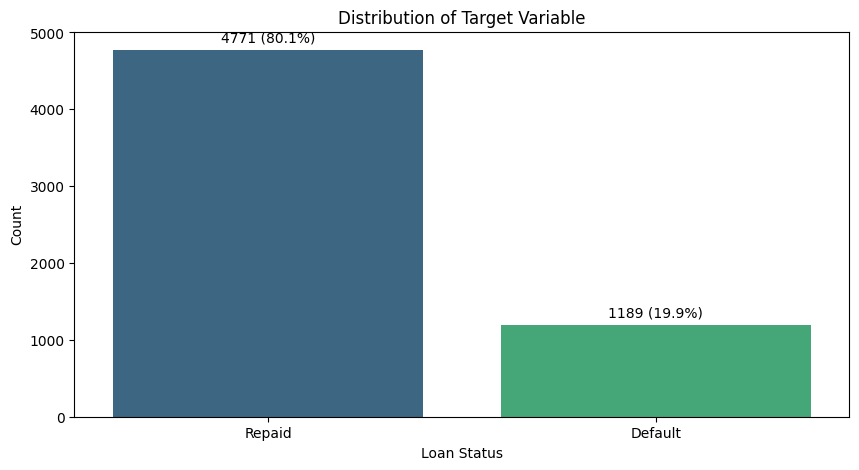

In [21]:
# this code calculates the value counts and percentages 'BAD'
BAD_counts = df['BAD'].value_counts()
BAD_perc = df['BAD'].value_counts(normalize=True) * 100

# this code creates a countplot of the distribution of 'BAD'
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='BAD_label', data=df_plot, palette ='viridis', order=['Repaid', 'Default'])
plt.title('Distribution of Target Variable')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# this code annotates each bar with the count and percentage
for index, p in enumerate(ax.patches):
    height = p.get_height()
    total = len(df_plot['BAD_label'])
    percentage = BAD_perc.iloc[index] # BAD_perc already has the correct order (0 then 1)
    ax.annotate(f'{int(height)} ({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')
plt.show()

####Observations:

* The target variable `BAD` has two values (0 or 1).

* `1` indicates the client defaulted while `O` indicates the client did not default hence the loan was repaid.

* The `BAD` column has no missing values hence this plot presents an accurate visualization of the data.

* Majority of the clients, that is, 80.1% repaid the loan while 19.9% defaulted on the loan.

### Distribution and Correlation of Numeric Variables

* The `BAD` variable has already been assessed hence the other numeric variables will be visualized.

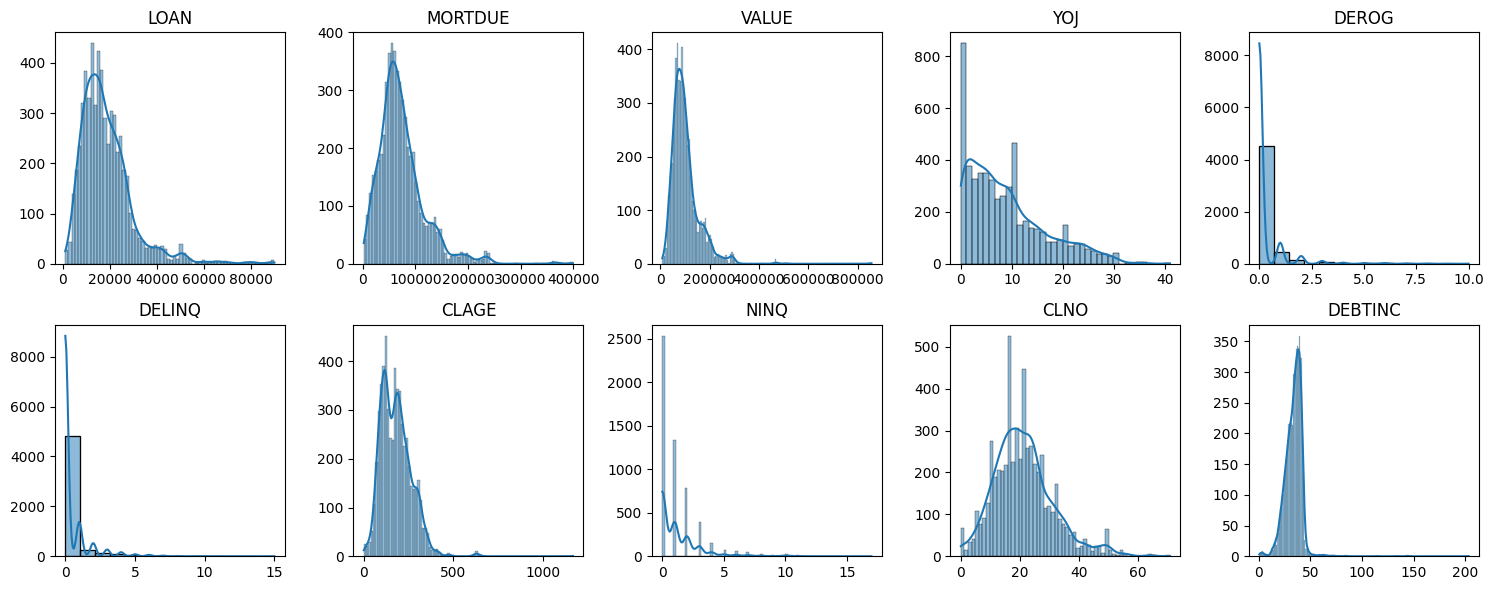

In [22]:
# this code exludes 'BAD' and calculates the number of rows for the subplot
cols_no_bad = [col for col in num_cols if col != 'BAD']
n_rows = (len(cols_no_bad) + 5 - 1) // 5

# this code creates a subplot to show the distribution of numeric columns
fig, axes = plt.subplots(nrows=n_rows, ncols=5, figsize=(5 * 3, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_no_bad):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# this code hides all unsed subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

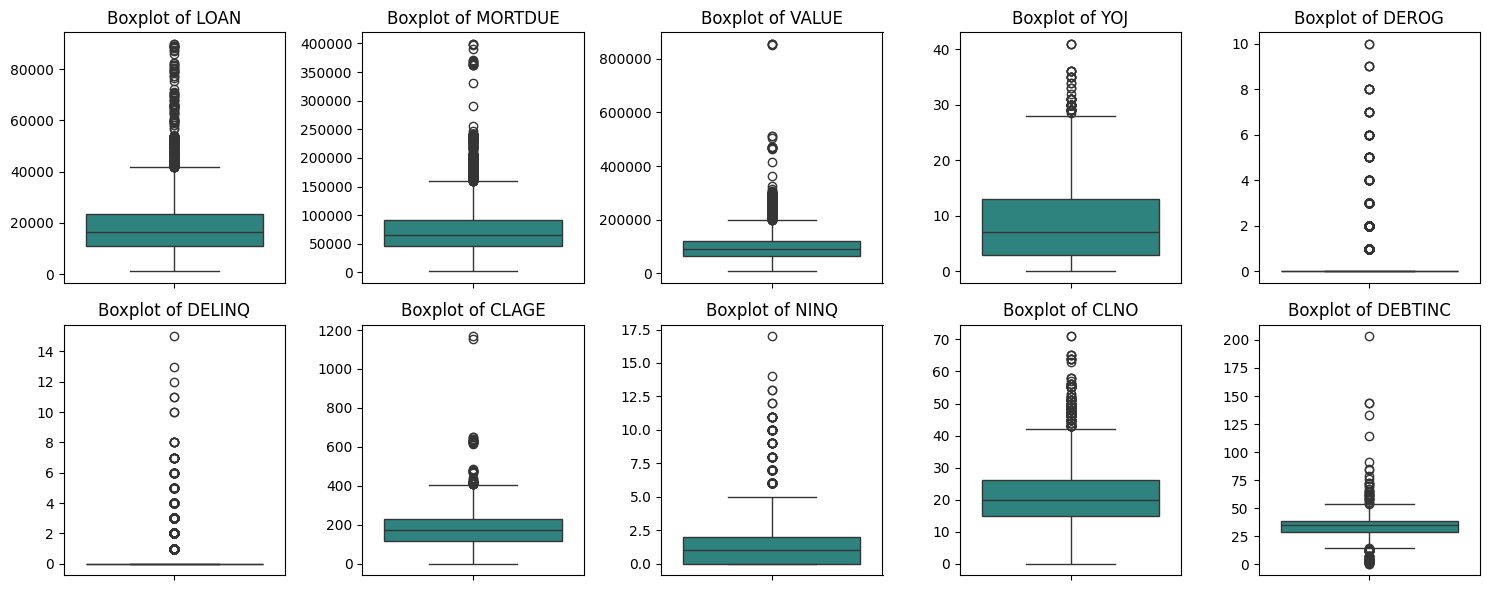

In [23]:
# this code creates a box and whisker plot to visualize the outliers of the numeric variables
n_rows = math.ceil(len(cols_no_bad)/5)
fig, axes = plt.subplots(nrows=n_rows, ncols=5, figsize=(5 * 3, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols_no_bad):
    sns.boxplot(y=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

# this code hides all unsed subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

###Observation

* LOAN: The distribution for loan amounts is right-skewed, with a significant concentration at the lower end. There are also clear outliers indicating that some client took large loan amounts.
* MORTDUE: The mortgage due is also right-skewed. Most clients have lower mortgage amounts, but there are a significant outliers representing very high mortgage amounts.
* VALUE: The property values are right-skewed distribution, with the majority of properties having lower values. There are outliers indicating very high-valued properties.
* YOJ: This distribution is highly right-skewed, indicating that most clients have been in their current job for fewer years. There are also outliers representing individuals who have been at their current jobs for long.
* DEROG: This column is extremely right-skewed, with the vast majority of values concentrated at 0. This means most clients have no derogatory reports. However, there are significant outliers indicating a small number of clients with a high number of derogatory reports.
* DELINQ: This is similar to DEROG, where the distribution is highly right-skewed, with most values at 0. This suggests that the majority of clients have no delinquent credit lines, but there are outliers for those who do.
* CLAGE: The distribution for the age of the oldest credit line is right-skewed. Many clients have relatively shorter credit histories, but there are outliers extending to very long credit histories.
* NINQ: This distribution is also right-skewed, indicating that most clients have made fewer recent credit inquiries. There are outliers representing clients with a higher number of inquiries.
* CLNO: This variable appears more symmetrically distributed than the other variables, although it is still slightly right-skewed..
* DEBTINC: The debt-to-income ratio is right-skewed, with most clients having lower ratios. However, there are significant outliers representing individuals with very high debt-to-income ratios.

## Bivariate Analysis


### Target Variable (BAD) vs Some Numerical Variables (DEBTINC, CLAGE, CLNO)

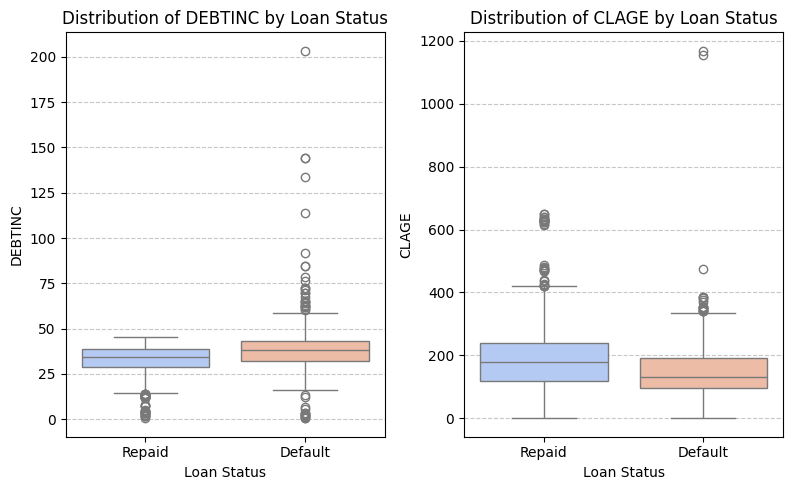

In [24]:
# this code creates a boxplot of the other numeric variables against BAD
columns = ['DEBTINC', 'CLAGE']
num_var = [col for col in columns]

n_cols_per_row = 4
n_rows = math.ceil(len(num_var) / n_cols_per_row)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols_per_row, figsize=(n_cols_per_row * 4, n_rows * 5))
axes = axes.flatten()


for i, col in enumerate(num_var):
    sns.boxplot(x='BAD_label', y=col, data=df_plot, palette='coolwarm', ax=axes[i], order=['Repaid', 'Default'])
    axes[i].set_title(f'Distribution of {col} by Loan Status')
    axes[i].set_xlabel('Loan Status')
    axes[i].set_ylabel(f'{col}')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Categorical Variables

#### BAD vs REASON

BAD_label  Default  Repaid   All
REASON                          
All           1141    4567  5708
DebtCon        745    3183  3928
HomeImp        396    1384  1780
------------------------------------------------------------------------------------------------------------------------


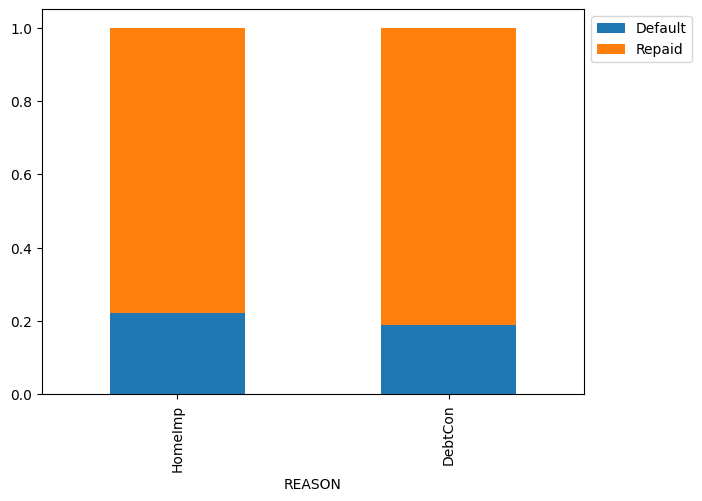

In [25]:
stacked_barplot(df_plot, 'REASON', 'BAD_label')

#### BAD vs JOB

BAD_label  Default  Repaid   All
JOB                             
All           1166    4515  5681
Other          554    1834  2388
ProfExe        212    1064  1276
Mgr            179     588   767
Office         125     823   948
Self            58     135   193
Sales           38      71   109
------------------------------------------------------------------------------------------------------------------------


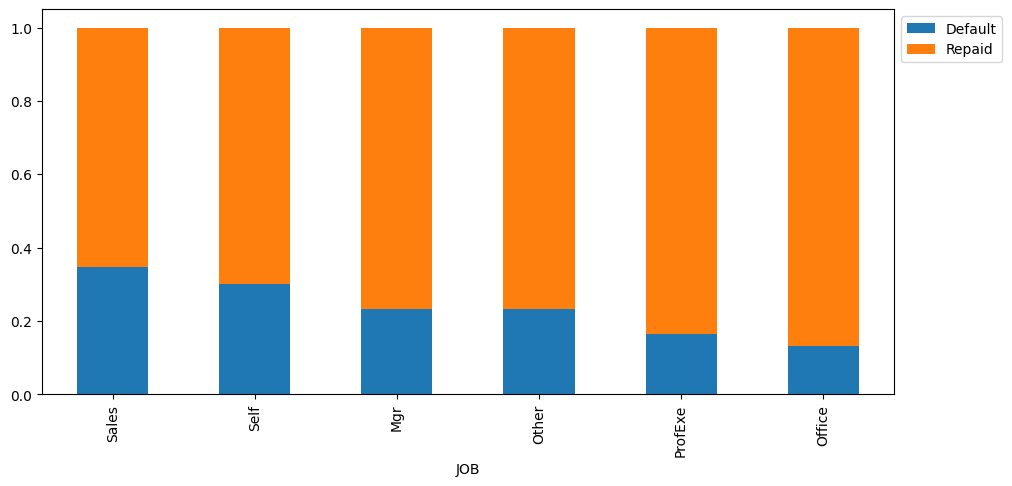

In [26]:
stacked_barplot(df_plot, 'JOB', 'BAD_label')

#### BAD vs YOJ

BAD_label    Default  Repaid   All
YOJ_bins                          
All             1124    4321  5445
1-10 Years       736    2512  3248
11-20 Years      260     965  1225
20+ Years         70     487   557
0 Years           58     357   415
------------------------------------------------------------------------------------------------------------------------


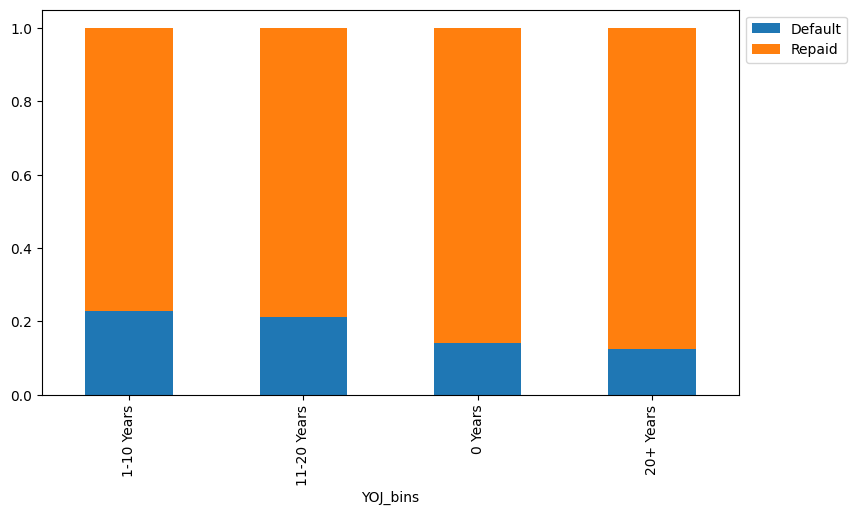

In [29]:
stacked_barplot(df_plot, 'YOJ_bins', 'BAD_label')

BAD_label    Default  Repaid   All
YOJ_bins                          
All             1124    4321  5445
1-10 Years       736    2512  3248
11-20 Years      260     965  1225
20+ Years         70     487   557
0 Years           58     357   415
------------------------------------------------------------------------------------------------------------------------


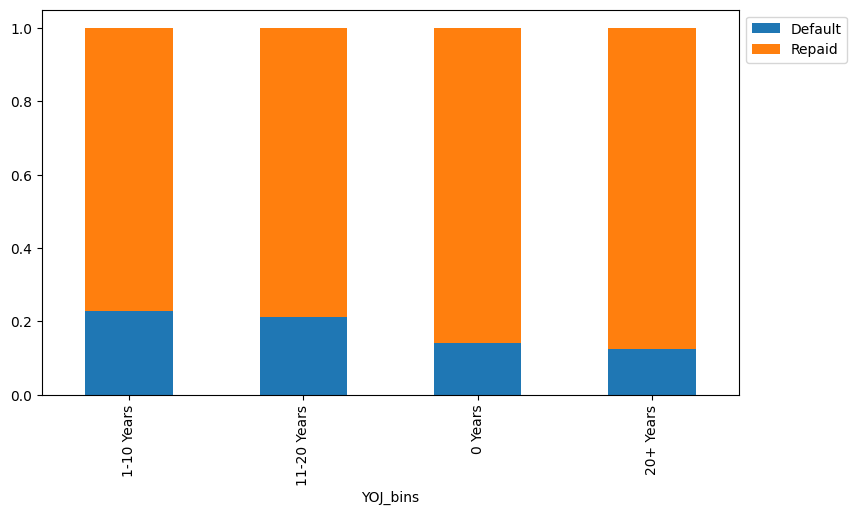

In [30]:
# this code prepares df_plot for creating bins and labels for 'YOJ'
df_plot = df.copy()
df_plot['BAD_label'] = df_plot['BAD'].map({0: 'Repaid', 1: 'Default'})

yoj_bins = [-1, 0, 10, 20, df_plot['YOJ'].max() + 1] # -1 to catch 0, max() + 1 to catch highest value
yoj_labels = ['0 Years', '1-10 Years', '11-20 Years', '20+ Years']

df_plot['YOJ_bins'] = pd.cut(df_plot['YOJ'], bins=yoj_bins, labels=yoj_labels, right=True, include_lowest=True)

stacked_barplot(df_plot, 'YOJ_bins', 'BAD_label')

# Data Preprocessing

## Removal of Unwanted Variables

- Based on the statistical summary and preliminary EDA, several columns have many missing values. The percentages of these missing values will be assessed and it may be prudent to consider dropping columns with above 50% missing values.

In [31]:
# this code calculate the percentage of missing values in each column
perc_missing_vals = (df.isnull().sum()/df.shape[0] * 100).to_frame(name='Percentage')
perc_missing_vals.sort_values(by='Percentage', ascending=False)

,Percentage
DEBTINC,21.258389
DEROG,11.879195
DELINQ,9.731544
MORTDUE,8.691275
YOJ,8.640940
NINQ,8.557047
CLAGE,5.167785
JOB,4.681208
REASON,4.228188
CLNO,3.724832


In [32]:
# this code removes columns with above 50% missing values
max_perc = 50
cols_to_drop = perc_missing_vals[perc_missing_vals['Percentage'] > max_perc].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)

if cols_to_drop:
    print(f"Columns with above {max_perc}% missing values have been dropped: {', '.join(cols_to_drop)}")
else:
    print(f"No columns were found with above {max_perc}% missing values.")

No columns were found with above 50% missing values.


###Observations:
* Based on the output, none of the columns have more than 50% missing values. The highest is DEBTINC with 21.25% and it is an important variable for this project.
* Additionally, the correlation matrix showed that although the correlations were weak, all the variables are important financial metric that potentially impact the target variable BAD.
* For these reasons, no variables will be removed.

## Feature Engineering

* The object-type columns were converted to categorical to conserve the memory and prevent runtime delays and errors.

* Some importance financial metric variables used in assessing loan default will be added.
  * These are: Loan-to-Value Ratio (LTV) and Home Equity.
  * LTV will be calculated using the LOAN and VALUE variables.'
  * The Home Equity will be calculated using the VALUE and MORTDUE variables.



In [33]:
# this code converts the object-type columns to categorical
df[cat_cols] = df[cat_cols].astype('category')

In [34]:
# this code finds the LTV ratio and Home Equity
df['LTV_ratio'] = df['LOAN'] / df['VALUE']

df['Home_Equity'] = df['VALUE'] - df['MORTDUE']

In [35]:
# this code defines the numeric columns
numeric_columns = num_cols
numeric_columns

['BAD',
 'LOAN',
 'MORTDUE',
 'VALUE',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC']

In [36]:
# this code includes the new variables to the numeric columns
numeric_columns.extend(['LTV_ratio', 'Home_Equity'])
numeric_columns

['BAD',
 'LOAN',
 'MORTDUE',
 'VALUE',
 'YOJ',
 'DEROG',
 'DELINQ',
 'CLAGE',
 'NINQ',
 'CLNO',
 'DEBTINC',
 'LTV_ratio',
 'Home_Equity']

## Data Preparation Pipelines

In [37]:
X = df.drop('BAD', axis=1)
y = df['BAD']

In [38]:
# this code splits the data
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# this code splits the remaining data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)

print(f"Original data shape: {X.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Original data shape: (5960, 14)
Training set shape: (3576, 14)
Validation set shape: (1192, 14)
Test set shape: (1192, 14)


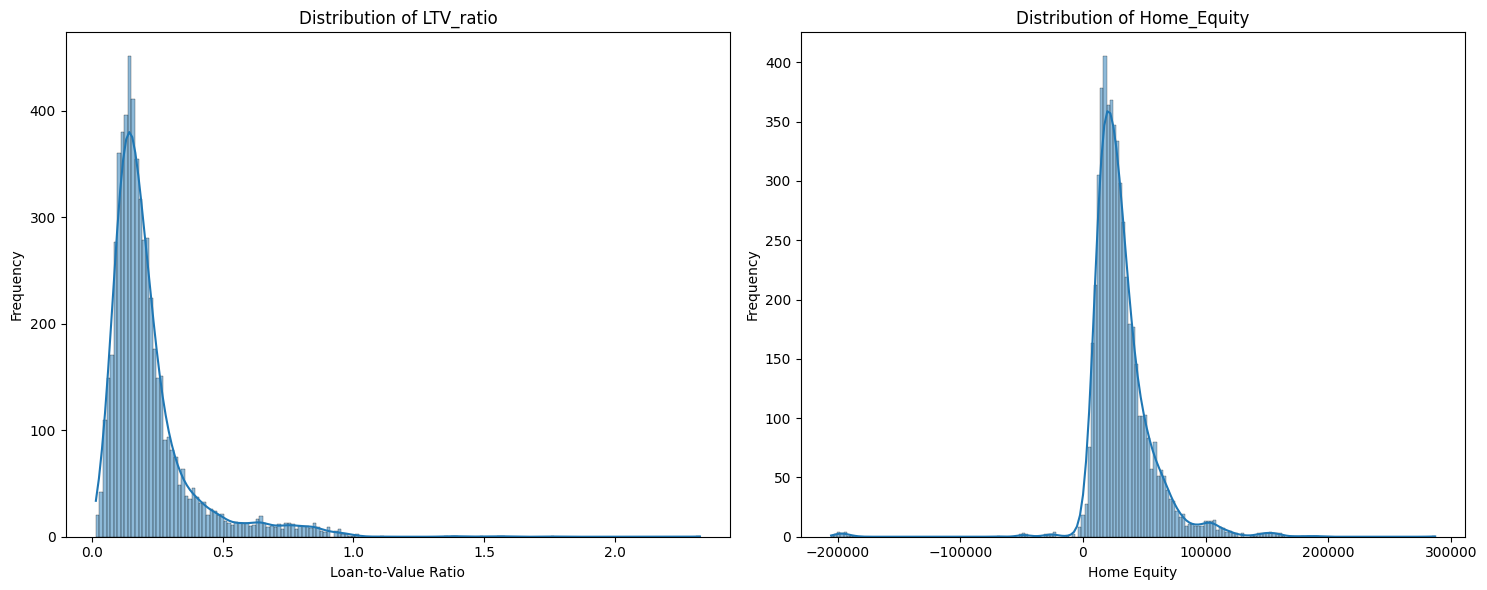

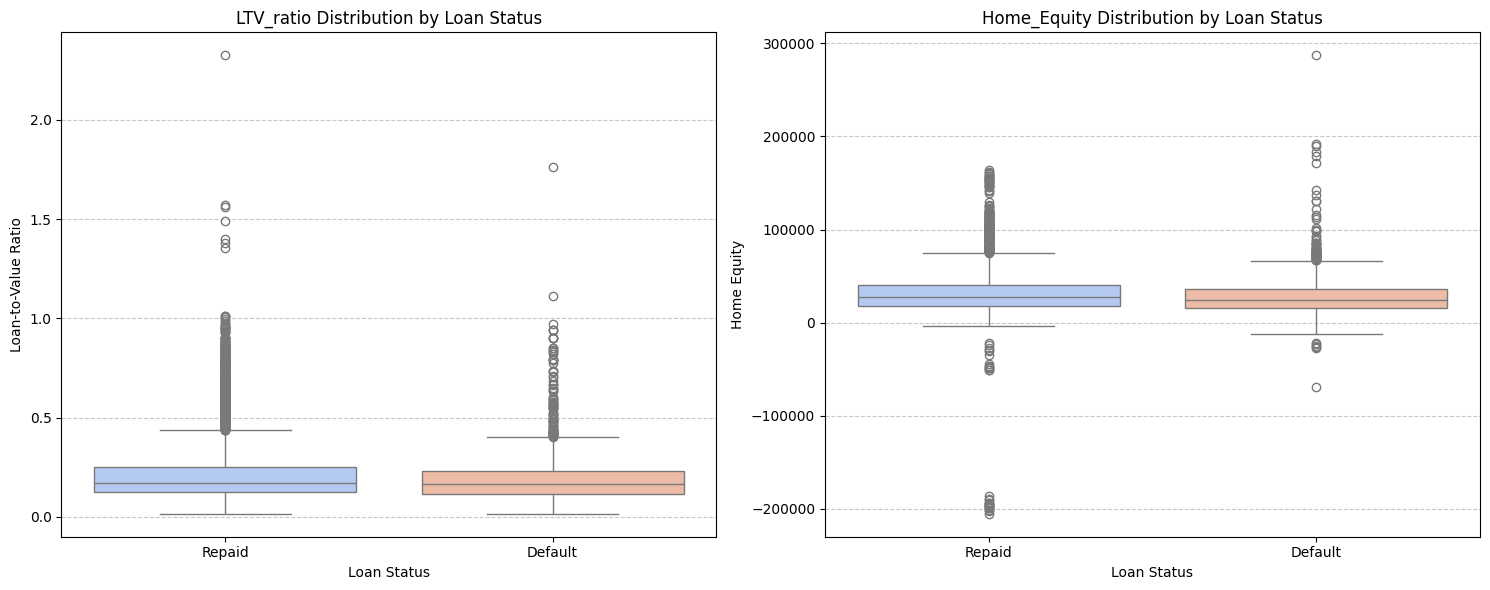

In [39]:
# this code creates a temporary column for plotting with descriptive labels for BAD
df_plot = df.copy()
df_plot['BAD_label'] = df_plot['BAD'].map({0: 'Repaid', 1: 'Default'})

# this code creates a plot for the distribution of LTV_ratio and Home_Equity
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_plot['LTV_ratio'].dropna(), kde=True)
plt.title('Distribution of LTV_ratio')
plt.xlabel('Loan-to-Value Ratio')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_plot['Home_Equity'].dropna(), kde=True)
plt.title('Distribution of Home_Equity')
plt.xlabel('Home Equity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Visualize LTV_ratio and Home_Equity against BAD (Loan Status) using box plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

sns.boxplot(x='BAD_label', y='LTV_ratio', data=df_plot, palette='coolwarm', ax=axes[0], order=['Repaid', 'Default'])
axes[0].set_title('LTV_ratio Distribution by Loan Status')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Loan-to-Value Ratio')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.boxplot(x='BAD_label', y='Home_Equity', data=df_plot, palette='coolwarm', ax=axes[1], order=['Repaid', 'Default'])
axes[1].set_title('Home_Equity Distribution by Loan Status')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Home Equity')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [40]:
# feature types
numerical_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X.columns if X[col].dtype == 'category']

# Identify skewed numerical features that should undergo log transformation
skewed_numerical_features_list = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'DEBTINC', 'LTV_ratio']
skewed_numerical_features = [col for col in skewed_numerical_features_list if col in numerical_features]

# Identify non-skewed numerical features, including 'Home_Equity' which can be negative and thus not log-transformed
non_skewed_numerical_features_list = ['CLNO', 'Home_Equity']
non_skewed_numerical_features = [col for col in non_skewed_numerical_features_list if col in numerical_features]


In [41]:
# this code defines a function for outlier capping to be used in FunctionTransformer
def outlier_capper_transformer(X_array):
    if X_array.ndim == 1:
        X_array = X_array.reshape(-1, 1)

    capped_X = np.empty_like(X_array, dtype=float)

    for i in range(X_array.shape[1]):
        col_data = X_array[:, i]
        lower_bound = np.percentile(col_data, 1)
        upper_bound = np.percentile(col_data, 99)
        capped_X[:, i] = np.clip(col_data, lower_bound, upper_bound)
    return capped_X

### Scaled Track Pipeline

The models to be used for the Scaled Track are:

* Logistic Regression
* K-Nearest Neighbours

In [42]:
# this code performs imputation, log transformation, outlier capping and scaling of the numerical features
skewed_num_pipeline_scaled = ImbPipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
    ('outlier_cap', FunctionTransformer(outlier_capper_transformer, validate=False)),
    ('scaler', StandardScaler())
])

In [43]:
non_skewed_num_pipeline_scaled = ImbPipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [44]:
cat_pipeline_scaled = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [45]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('skewed_num', skewed_num_pipeline_scaled, skewed_numerical_features),
        ('non_skewed_num', non_skewed_num_pipeline_scaled, non_skewed_numerical_features),
        ('cat', cat_pipeline_scaled, categorical_features)
    ],
    remainder='passthrough'
)

In [46]:
scaled_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

In [47]:
# this code performs imputation and log transformation for non skewed features
non_skewed_num_pipeline_scaled = ImbPipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [48]:
# this code performs imputation and One Hot Encoding for categorical features
cat_pipeline_scaled = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [49]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('skewed_num', skewed_num_pipeline_scaled, skewed_numerical_features),
        ('non_skewed_num', non_skewed_num_pipeline_scaled, non_skewed_numerical_features),
        ('cat', cat_pipeline_scaled, categorical_features)
    ],
    remainder='passthrough'
)

In [50]:
scaled_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

### Tree Track Pipeline

The models to be used for the Tree Track are:

* Decision Tree
* Random Forest
* Gradient Boosting
* XGBoost

In [51]:
# this code performs imputation
num_pipeline_tree = ImbPipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

In [52]:
# this code performs imputation and One Hot Encoding
cat_pipeline_tree = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [53]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', num_pipeline_tree, numerical_features),
        ('cat', cat_pipeline_tree, categorical_features)
    ],
    remainder='passthrough'
)

In [54]:
tree_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [55]:
# this code displays the pipelines
print("Scaled Pipeline Structure:")
print(scaled_pipeline)
print("\nTree Pipeline Structure:")
print(tree_pipeline)

Scaled Pipeline Structure:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('skewed_num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('outlier_cap',
                                                                   FunctionTransformer(func=<function outlier_capper_transformer at 0x79a6b890d940>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LOAN', '

# Modeling Process


## Models for Scaled Track (Logistic Regression, K-Nearest Neighbouts)

In [56]:
# this code defines the models for the Scaled Track
models_scaled = {
    'Logistic Regression': LogisticRegression(solver='liblinear', random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

## Models for Tree Track (Decision Tree, Random Forest, Gradient Boosting, XGBoost)


In [57]:
# this code defines the models for the Tree Track
models_tree = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
}

## Model Training and Hyperparameter Tuning

In [58]:
# this code defines the parameter grids for each model
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    },
    'K-Nearest Neighbors': {
        'classifier__n_neighbors': [3, 5, 7, 9],
        'classifier__weights': ['uniform', 'distance'],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    },
    'Decision Tree': {
        'classifier__max_depth': [None, 5, 10, 15],
        'classifier__min_samples_split': [2, 5, 10],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 5, 10],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'smote__sampling_strategy': ['auto', 0.5, 0.75, 1.0]
    }
}

In [59]:
# this code creates a dictionary to store the best models and their performance
best_models = {}
model_results = []

In [60]:
# this code iterates through each model and performs GridSearchCV
for model_name, model in models_scaled.items():
    print(f"\n--- Tuning {model_name} (Scaled Track) ---")

    # this code sets the classifier in the pipeline
    scaled_pipeline.set_params(classifier=model)

    # this code gets parameters for the current model
    current_param_grid = param_grids[model_name]

    grid_search = GridSearchCV(scaled_pipeline, current_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_

    # this code evaluates the validation set
    y_pred_val = grid_search.best_estimator_.predict(X_val)
    y_proba_val = grid_search.best_estimator_.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val)

    model_results.append({
        'Model': model_name,
        'Track': 'Scaled',
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Validation ROC-AUC: {roc_auc:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Precision: {precision:.4f}")
    print(f"Validation Recall: {recall:.4f}")
    print(f"Validation F1-Score: {f1:.4f}")


--- Tuning Logistic Regression (Scaled Track) ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters for Logistic Regression: {'classifier__C': 0.01, 'smote__sampling_strategy': 0.75}
Validation ROC-AUC: 0.7856
Validation Accuracy: 0.7676
Validation Precision: 0.4389
Validation Recall: 0.5882
Validation F1-Score: 0.5027

--- Tuning K-Nearest Neighbors (Scaled Track) ---
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Parameters for K-Nearest Neighbors: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance', 'smote__sampling_strategy': 'auto'}
Validation ROC-AUC: 0.9173
Validation Accuracy: 0.9169
Validation Precision: 0.8294
Validation Recall: 0.7353
Validation F1-Score: 0.7795


In [61]:
# this code iterates through each model and performs GridSearchCV
for model_name, model in models_tree.items():
    print(f"\n--- Tuning {model_name} (Tree Track) ---")

    # this code sets the classifier in the pipeline
    tree_pipeline.set_params(classifier=model)

    # this code gets parameters for the current model
    current_param_grid = param_grids[model_name]

    grid_search = GridSearchCV(tree_pipeline, current_param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)

    best_models[model_name] = grid_search.best_estimator_

    # this code evaluates the validation set
    y_pred_val = grid_search.best_estimator_.predict(X_val)
    y_proba_val = grid_search.best_estimator_.predict_proba(X_val)[:, 1]

    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    recall = recall_score(y_val, y_pred_val)
    f1 = f1_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_proba_val)

    model_results.append({
        'Model': model_name,
        'Track': 'Tree',
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")
    print(f"Validation ROC-AUC: {roc_auc:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Precision: {precision:.4f}")
    print(f"Validation Recall: {recall:.4f}")
    print(f"Validation F1-Score: {f1:.4f}")


--- Tuning Decision Tree (Tree Track) ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Parameters for Decision Tree: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2, 'smote__sampling_strategy': 0.5}
Validation ROC-AUC: 0.8345
Validation Accuracy: 0.8591
Validation Precision: 0.6241
Validation Recall: 0.7395
Validation F1-Score: 0.6769

--- Tuning Random Forest (Tree Track) ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters for Random Forest: {'classifier__max_depth': None, 'classifier__n_estimators': 200, 'smote__sampling_strategy': 0.5}
Validation ROC-AUC: 0.9698
Validation Accuracy: 0.9329
Validation Precision: 0.9202
Validation Recall: 0.7269
Validation F1-Score: 0.8122

--- Tuning Gradient Boosting (Tree Track) ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters for Gradient Boosting: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'sm

In [62]:
# this code displays the summary of results
results_df = pd.DataFrame(model_results)
display(results_df.sort_values(by='ROC-AUC', ascending=False))

,Model,Track,Best Params,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,Tree,"{'classifier__max_depth': None, 'classifier__n...",0.932886,0.920213,0.726891,0.812207,0.969800
5,XGBoost,Tree,"{'classifier__learning_rate': 0.2, 'classifier...",0.931208,0.875000,0.764706,0.816143,0.964576
4,Gradient Boosting,Tree,"{'classifier__learning_rate': 0.2, 'classifier...",0.933725,0.887805,0.764706,0.821670,0.963158
1,K-Nearest Neighbors,Scaled,"{'classifier__n_neighbors': 7, 'classifier__we...",0.916946,0.829384,0.735294,0.779510,0.917270
2,Decision Tree,Tree,"{'classifier__max_depth': 5, 'classifier__min_...",0.859060,0.624113,0.739496,0.676923,0.834476
0,Logistic Regression,Scaled,"{'classifier__C': 0.01, 'smote__sampling_strat...",0.767617,0.438871,0.588235,0.502693,0.785556


# Model Comparison

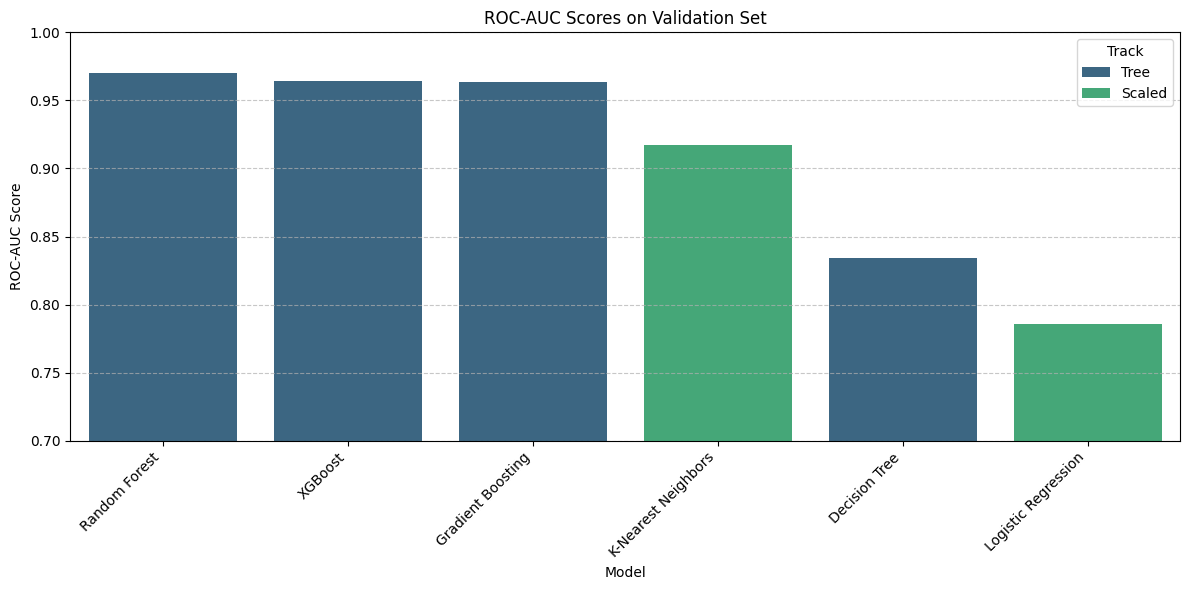

In [63]:
# this code visualizes the ROC-AUC of the models
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='ROC-AUC', hue='Track', data=results_df.sort_values(by='ROC-AUC', ascending=False), palette='viridis')
plt.title('ROC-AUC Scores on Validation Set')
plt.xlabel('Model')
plt.ylabel('ROC-AUC Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

* The tree-based models (Random Forest, XGBoost, Gradient Boosting) and K-Nearest Neighbors perform significantly better in terms of ROC-AUC compared to Logistic Regression.


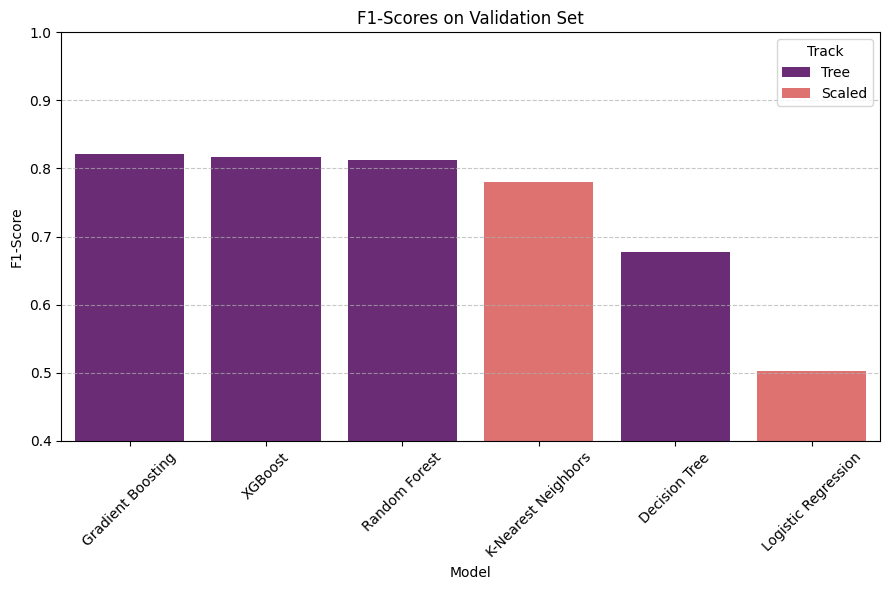

In [64]:
# this code visualizes the F1-Score of the models
fig, axes = plt.subplots(1, 1, figsize=(9, 6))

sns.barplot(x='Model', y='F1-Score', hue='Track', data=results_df.sort_values(by='F1-Score', ascending=False), palette='magma', ax=axes)
axes.set_title('F1-Scores on Validation Set')
axes.set_xlabel('Model')
axes.set_ylabel('F1-Score')
axes.tick_params(axis='x', rotation=45)
axes.set_ylim(0.4, 1.0)
axes.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

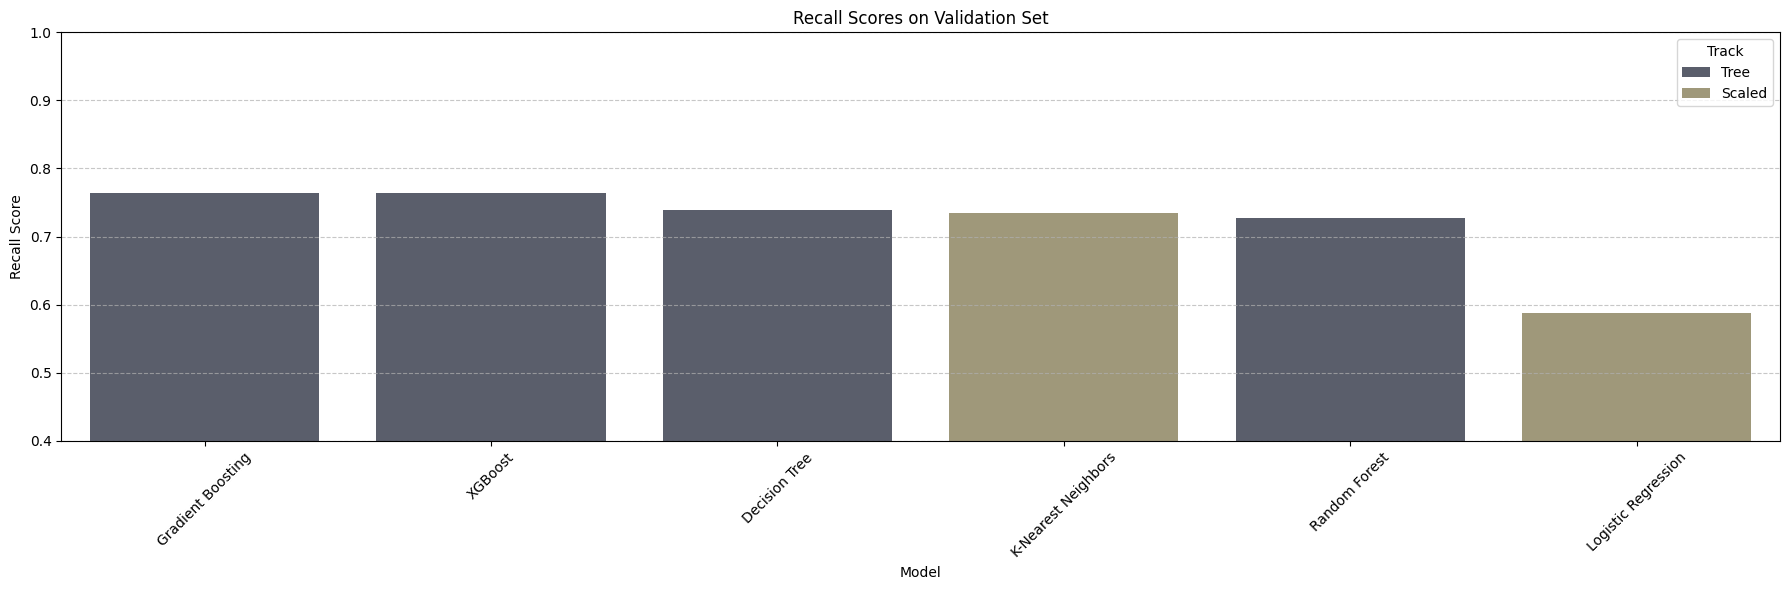

In [65]:
# this code visualizes the Recall scores of the models
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

sns.barplot(x='Model', y='Recall', hue='Track', data=results_df.sort_values(by='Recall', ascending=False), palette='cividis', ax=axes)
axes.set_title('Recall Scores on Validation Set')
axes.set_xlabel('Model')
axes.set_ylabel('Recall Score')
axes.tick_params(axis='x', rotation=45)
axes.set_ylim(0.4, 1.0)
axes.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

These plots provide a more detailed view of the F1-Score and Recall.
*   **F1-Score**: Gradient Boosting, XGBoost and Random Forest show very strong F1-Scores, indicating a good balance between precision and recall.

*   **Recall**: Gradient Boosting, XGBoost and Decision Tree have competitive recall scores, which is crucial for identifying as many defaulters as possible. Decision Tree also shows a decent recall.

Based on these visualizations, it appears that **Gradient Boosting** outperforms the other models.

# Model Interpretation and Evaluation

### Model Evaluation on Test Set

In [67]:
best_gb_model = best_models['Gradient Boosting']
y_pred_test = best_gb_model.predict(X_test)
y_proba_test = best_gb_model.predict_proba(X_test)[:, 1]

# this code calculates the evaluation metrics
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

print(f"--- Gradient Boosting Model Performance on Test Set ---")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print(f"ROC-AUC: {roc_auc_test:.4f}")

--- Gradient Boosting Model Performance on Test Set ---
Accuracy: 0.9203
Precision: 0.9040
Recall: 0.6723
F1-Score: 0.7711
ROC-AUC: 0.9597


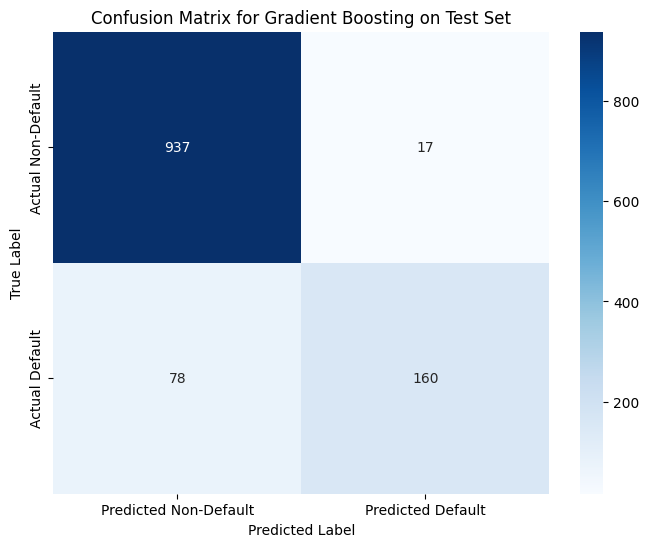

In [68]:
# this code creates a confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
plt.title('Confusion Matrix for Gradient Boosting on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [69]:
# this code displays the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       954
           1       0.90      0.67      0.77       238

    accuracy                           0.92      1192
   macro avg       0.91      0.83      0.86      1192
weighted avg       0.92      0.92      0.92      1192



### Adjusting the threshold

In [70]:
thresholds = np.arange(0.1, 1.0, 0.05)
metrics_threshold = []



for t in thresholds:
    y_pred_threshold = (y_proba_test >= t).astype(int)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
    metrics_threshold.append({'Threshold': t, 'Precision': precision, 'Recall': recall, 'F1-Score': f1})

threshold_df = pd.DataFrame(metrics_threshold)

display(threshold_df.round(4))


,Threshold,Precision,Recall,F1-Score
0,0.10,0.8077,0.7941,0.8008
1,0.15,0.8356,0.7689,0.8009
2,0.20,0.8411,0.7563,0.7965
3,0.25,0.8462,0.7395,0.7892
4,0.30,0.8657,0.7311,0.7927
5,0.35,0.8808,0.7143,0.7889
6,0.40,0.8895,0.7101,0.7897
7,0.45,0.8919,0.6933,0.7801
8,0.50,0.9040,0.6723,0.7711
9,0.55,0.9138,0.6681,0.7718


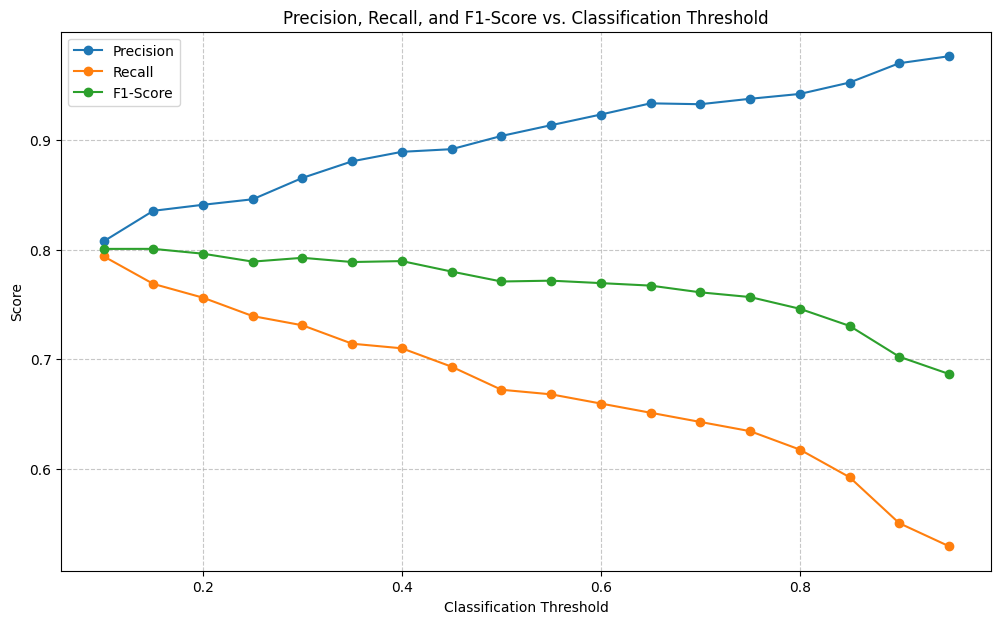

In [71]:
plt.figure(figsize=(12, 7))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision', marker='o')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall', marker='o')
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], label='F1-Score', marker='o')

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score vs. Classification Threshold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


--- Gradient Boosting Model Performance on Test Set (Threshold = 0.1) ---
Accuracy: 0.9211
Precision: 0.8077
Recall: 0.7941
F1-Score: 0.8008
ROC-AUC: 0.9597

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       954
           1       0.81      0.79      0.80       238

    accuracy                           0.92      1192
   macro avg       0.88      0.87      0.88      1192
weighted avg       0.92      0.92      0.92      1192



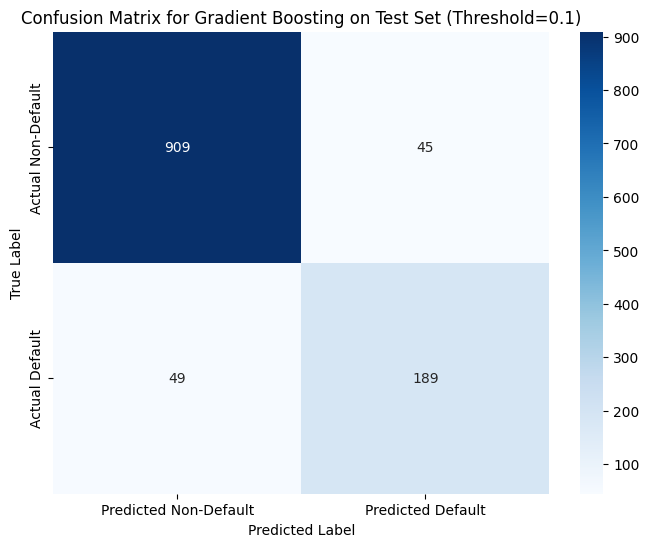

In [72]:
new_threshold = 0.10
y_pred_adjusted = (y_proba_test >= new_threshold).astype(int)


accuracy_adjusted = accuracy_score(y_test, y_pred_adjusted)
precision_adjusted = precision_score(y_test, y_pred_adjusted)
recall_adjusted = recall_score(y_test, y_pred_adjusted)
f1_adjusted = f1_score(y_test, y_pred_adjusted)
roc_auc_adjusted = roc_auc_score(y_test, y_proba_test)

print(f"--- Gradient Boosting Model Performance on Test Set (Threshold = {new_threshold}) ---")
print(f"Accuracy: {accuracy_adjusted:.4f}")
print(f"Precision: {precision_adjusted:.4f}")
print(f"Recall: {recall_adjusted:.4f}")
print(f"F1-Score: {f1_adjusted:.4f}")
print(f"ROC-AUC: {roc_auc_adjusted:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_adjusted))

cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_adjusted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Non-Default', 'Predicted Default'],
            yticklabels=['Actual Non-Default', 'Actual Default'])
plt.title(f'Confusion Matrix for Gradient Boosting on Test Set (Threshold={new_threshold})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Importance of Gradient Boosting Model

In [73]:
# this code retrieves the best Gradient Boosting model
best_gb_model = best_models['Gradient Boosting']

# this code accesses the preprocessor from the best model's pipeline
preprocessor = best_gb_model.named_steps['preprocessor']

In [74]:
# this code gets the feature names after one-hot encoding
cat_ohe_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# this code combines the original numerical features with one-hot encoded categorical features
processed_features = list(skewed_numerical_features) + list(non_skewed_numerical_features) + list(cat_ohe_features)

In [75]:
# this code gets the feature importances from the trained classifier
feature_importances = best_gb_model.named_steps['classifier'].feature_importances_

In [76]:
# this code creates a DataFrame for the important features
importance_df = pd.DataFrame({'Feature': processed_features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


In [77]:
# this code displays the top 20 most important features
print("Top 20 Feature Importances:")
display(importance_df.head(20))

Top 20 Feature Importances:


,Feature,Importance
5,DELINQ,0.305524
9,LTV_ratio,0.142863
6,CLAGE,0.082293
4,DEROG,0.076242
7,NINQ,0.046482
3,YOJ,0.041393
1,MORTDUE,0.037226
11,Home_Equity,0.034912
0,LOAN,0.034199
8,DEBTINC,0.030959


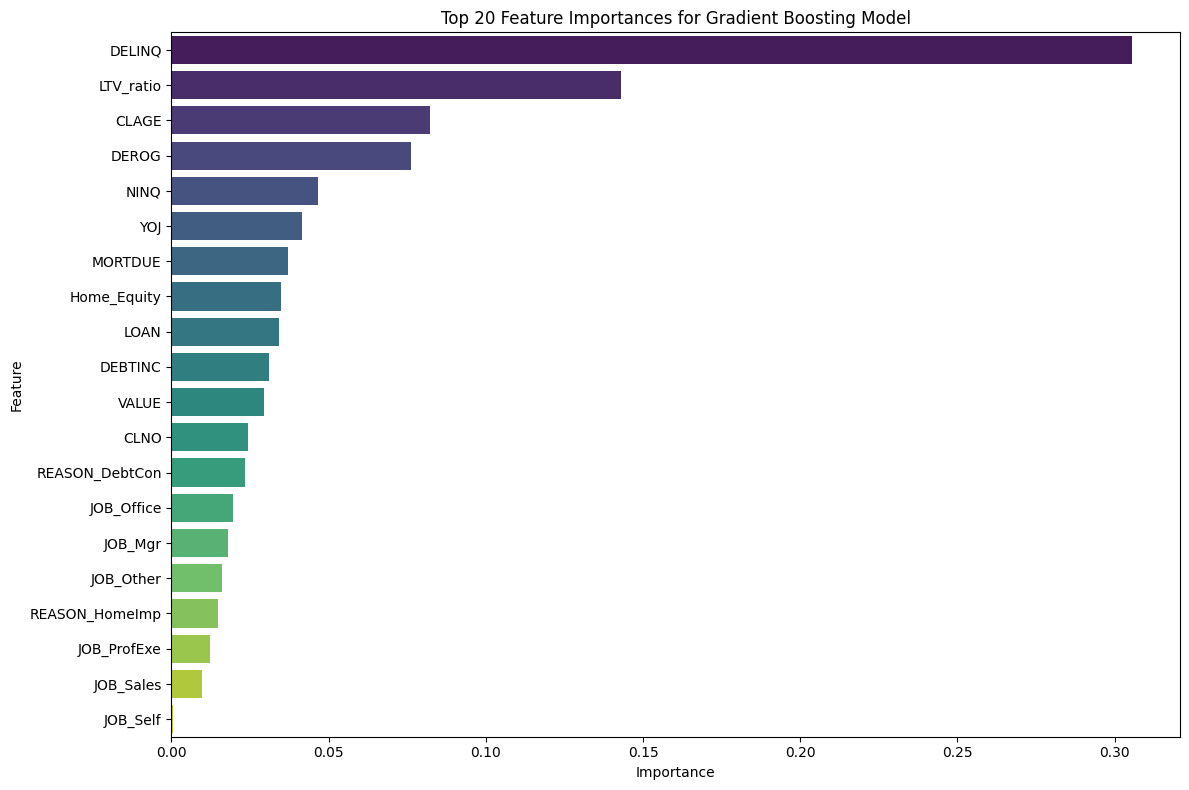

In [78]:
# this code visualizes the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances for Gradient Boosting Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()